# Exercise 2 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: zitian wang

Sciper number: 423090

#### Group Member 2:
Name: Yunyi Chen

Sciper number: 423371

#### Group Member 3:
Name: Xinran Wang

Sciper number: 416485

#### Group Member 4:
Name: Tianrui Hu

Sciper number: 415043

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

We used AI tools such as ChatGPT, Gemini etc as study support tools to help us understand the main points of the lectures, clarify some concepts, and improve the structure and formatting of our written answers.

More specifically, it was used for:
- summarizing and explaining key ideas from the lectures,
- helping us better understand the logic behind some methods,
- polishing the wording and markdown format of our answers.

All final answers, derivations, and code were reviewed by us, and we verified the final content ourselves before submission.

# Linear Programming exercise

In [1]:
### Do the imports -- no need to change this
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

In [2]:
reward_mode = 2 # see below to visualize the reward function
size = 3 # size of the gridworld (3x3)
prop = 0.1 # proportion of randomly taken steps due to noise in the environment 
gamma=0.99 # discount factor

gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
print('Reward function: \n', gridworld.r) # visualize the reward function

Reward function: 
 [[   0.    0.    0.    0.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [-100. -100. -100. -100.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]]


We will use a solver to compute the **optimal value function** to measure the suboptimality of the policies produced by our algorithms.

To access the optimal value function use `solver.v`.

In [3]:
solver = MDPsolver(gridworld) # call the MDPsolver class
solver.value_iteration() # call the value iteration method to find V^* once

## Ex 1: Solving the Primal [20 points]

We will leverage the powerful `scipy` library to solve **Linear Programs (LPs)**. Below we give an example of using the [linprog module](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html) to solve a simple LP:

\begin{aligned}
 & \min_{x := \begin{bmatrix}
x_0  \\
x_1
\end{bmatrix}  \in \mathbb{R}^2}  \begin{bmatrix}
-1  \\
4
\end{bmatrix} ^\top x
\\&  \text{s.t.}  \begin{bmatrix}
-3 & 1 \\
1 & 2 
\end{bmatrix} \mathbb{x} \le  \begin{bmatrix}
6  \\
4 
\end{bmatrix} , \quad  x_1\ge -3 \,.
\end{aligned}

The **code example below will be instructive** when you later construct the LP corresponding to the MDP.

In [4]:
from scipy.optimize import linprog # import the linear programming solver from scipy

# Note that the bounds argument in linprog is a  sequence of (min, max) pairs for each element in x, defining the minimum and maximum values.
x0_bounds = (None, None)
x1_bounds = (-3, None)

# call linear programming solver:
res = linprog([-1, 4], 
              A_ub=[[-3, 1], [1, 2]], 
              b_ub=[6, 4], 
              bounds=[x0_bounds, x1_bounds],
              method="simplex")
print('The solution is ', res.x) # access and print the solution
print(res.message) # print the message of the solver (e.g., terminated successfully)

The solution is  [10. -3.]
Optimization terminated successfully.


/var/folders/w8/l15fldh90_lb5mkvnpcjjq5m0000gp/T/ipykernel_64928/2674117054.py:8: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog([-1, 4],


Now we are ready to use `linprog` to solve the LP problem in gridworld.

We define a distribution `mu` over the states.

In [5]:
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu
# Uniform distribution over states, thus the probability of each state is (1/S)

Next, we need to **instantiate the constraints of the primal problem**. Notice that `scipy` requires the inequality constraints in the form $A_{ub} x \leq b_{ub}$.


To this end, we rewrite the constraint $EV \geq \gamma P V + r$ in the form expected by `scipy`.

In [6]:
def build_matrix(env):
    E = np.kron(np.eye(env.n_states), np.ones(env.n_actions)).T # build the matrix E
    P = env.T.transpose((1,0,2)).reshape(env.n_states*env.n_actions, -1) # build the matrix P (Already reshaped)
    return env.gamma*P - E

(Side remark: The indexing in the matrices `E` and `P` here is slightly different from the one in the lecture. This does not change any of the formulas from the slides since both matrices are indexed in the same way, consistently throughout this exercise. You may ignore this comment.)

Then, use the function `linprog` of `scipy` to solve the dual problem and show that you can retrieve the same $V^\star$ computed with the solver and stored in `solver.v`

In [7]:
# Call linear programming solver with the correct inputs:
primal_out = linprog(((1-gridworld.gamma) * mu).reshape(-1), # Reshape to 1D array
                     A_ub=build_matrix(gridworld), 
                     b_ub=-gridworld.r.reshape(-1),
                     method="simplex",
                     bounds=[(None, None)] * gridworld.n_states)

/var/folders/w8/l15fldh90_lb5mkvnpcjjq5m0000gp/T/ipykernel_64928/2287986272.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out = linprog(((1-gridworld.gamma) * mu).reshape(-1), # Reshape to 1D array


(*Hint:* Check slide 23 for the matrix form (or slide 8), lecture 3 to recall the primal.)

We can access the solution of the primal LP using `primal_out.x`. Compare the error with the value of `solver.v`.

In [8]:
np.linalg.norm(primal_out.x - solver.v) # plot 2-norm

np.float64(4.111484296790486e-14)

***Question***

By running the following two cells, plot (in matrix form) `mu` and the difference between `solver.v` and `primal_out.x`. Then, answer the following question: Can we ensure that `np.linalg.norm(primal_out.x - solver.v)` is zero (up to numerical errors) for the current value of `mu`?  

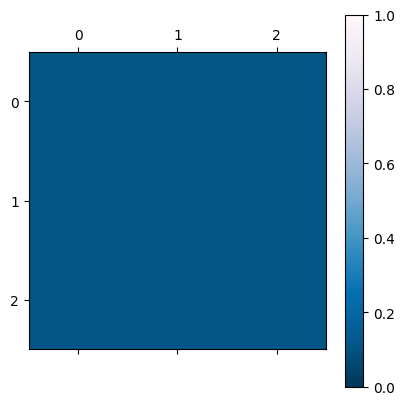

In [9]:
plt.matshow(mu.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states 
plt.colorbar()

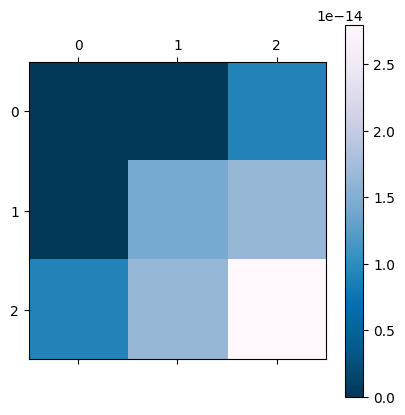

In [10]:
plt.matshow((solver.v - primal_out.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer**

For the current value of mu, we can say that the solution of the primal LP should be the same as solver.v in theory. This is because mu is initialized as a uniform distribution over all states, so every entry of mu is strictly positive. 

In the lecture 3 page 10, it is explained that if all entries of mu are positive, then the primal LP has a unique optimal solution, and this solution is exactly the optimal value function V*. Since solver.v is also the optimal value function, the two results should match.

Besides, from the plots, we can also see that mu gives the same weight to every state. This means the objective function does not ignore any state. Because of that, the LP is forced to choose the lowest feasible value function for all states, and that value function is V*. So for this choice of mu, we can ensure that primal_out.x and solver.v are the same in exact theory.

However, in actual computation, we cannot expect np.linalg.norm(primal_out.x - solver.v) to be exactly zero. The reason is that the LP solver uses floating-point arithmetic, and small numerical errors always appear during computation. Also, the stopping rule of the solver has some tolerance, so the final answer is usually only approximately exact. That is why we get a value like 4 × 10^-14 instead of 0.


Next, we repeat the same experiment with a different value of `mu`. 

Note that we do **not** overwrite `mu` or `primal_out` (but instead have `mu2` and `primal_out2`, since for all other exercises, we will use the original, uniform `mu`.)

In [11]:
# overwrite mu with a new distribution:
mu2 = np.zeros((gridworld.n_states,1))
mu2[-3] = 1

Fill in the following, as before but for the distribution `mu2`.

In [12]:
# solve the LP with the new mu2:
primal_out2 = linprog(((1-gridworld.gamma) * mu2).reshape(-1), 
                      A_ub=build_matrix(gridworld), 
                      b_ub=-gridworld.r.reshape(-1),
                      method="simplex",
                      bounds=[(None, None)] * gridworld.n_states) # No upper or lower bounds on the variables

/var/folders/w8/l15fldh90_lb5mkvnpcjjq5m0000gp/T/ipykernel_64928/3070320947.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out2 = linprog(((1-gridworld.gamma) * mu2).reshape(-1),


We compare with the value computed by Value Iteration `solver.v`.

In [13]:
np.linalg.norm(primal_out2.x - solver.v) # plot 2-norm

np.float64(2.772246430099758)

Note that now, the optimal solution of the primal LP `primal_out2.x` and the optimal value function `solver.v` do not coincide anymore! 

This is despite the fact that the optimal value function `solver.v` was computed **right in the beginning**, before we even initialized the `mu` for solving the LP the first time. So `solver.v` is definitely the correct optimal value function for each state.

**Question:**

Why does it make sense that the two values do not coincide?

**Answer:**

Because the situation is different from the previous case. Specifically speaking, mu2 does not satisfy the condition mu(s) > 0 for all states.

Since almost all entries are zero in mu2 , and only one state has weight 1. This means the LP objective only cares about the value of that one state. For the other states, the objective does not directly try to make them as small as possible. Because of this, the LP can return another feasible value vector that gives the same minimum objective value at the weighted state, even if its values at other states are different from solver.v. So the LP solution does not need to coincide with the true optimal value function at every state.

The reason why the solver.v is still correct is that it uses value iteration. Value iteration computes the optimal value function from the Bellman optimality equation, and this does not depend on the choice of mu in the LP objective, which is the real optimal value function of the MDP itself. Meanwhile the LP with mu2 is solving the problem in an convex optimization view, where it is choosing one feasible value function that minimizes only the states emphasized by mu2. 

All in all, once this positivity condition is broken, the uniqueness result no longer applies. The LP is no longer forced to recover V* exactly on all states, and it may output another Bellman-feasible solution that is optimal for the objective defined by mu2, but not equal to solver.v everywhere.


***Question***

We plot again in matrix form `mu2`, `solver.v` and `primal_out2.x`. Then answer the following: What can happen in the states where `mu2 = 0`?

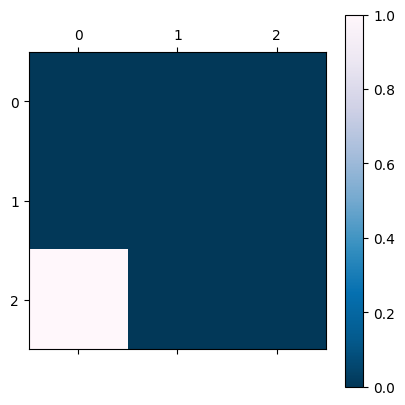

In [14]:
plt.matshow(mu2.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states
plt.colorbar()

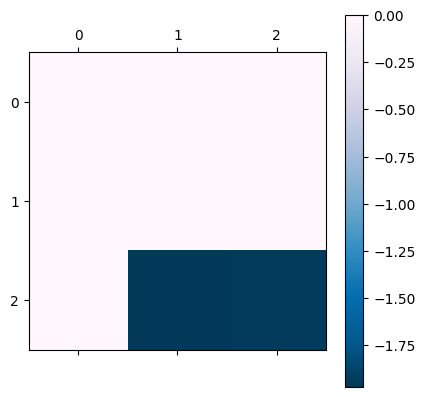

In [15]:
plt.matshow((solver.v - primal_out2.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer:**
As mentioned in the previous question, the objective only tries to minimize the value of the state that has positive weight in mu2. So for the states with zero probability, the LP solver is free to choose any values.

Therefore, the values in the states with mu2 = 0 do not have to be equal to the true optimal value function solver.v. But they have still satisfy the Bellman inequality constraints, which means that they can be different but they should be larger than V*. Because it's introduced in the lecture that any feasible value function satisfies V ≥ V*. 

From the second plot we can see that solver.v - primal_out2.x is negative at the last two states, which means primal_out2.x is bigger than solver.v (V*). The reason is that these states are not penalized in the objective, so the LP does not try to make them as small as possible. It only needs them to remain feasible. Thus the solver may leave some slack in those states.This is why the LP can still be optimal for mu2, while not matching the true optimal value function in every state.

# Ex 2: Solving the Dual [20 points]

Try now to solve the dual using again the `linprog` routine of scipy. 

Note that we did **not** overwrite `mu` (i.e. it is still uniform, and `primal_out.x` is the primal solution for this `mu`).

(*Hint:* Check slide 23 for the matrix form (or slide 11), lecture 3 to recall the dual.)

In [16]:
# solve the dual LP with the correct inputs:
dual_out = linprog(-gridworld.r.reshape(-1), 
              A_eq= build_matrix(gridworld).T, 
              b_eq= -(1 - gridworld.gamma)*mu, # original code in the question
              method="simplex",
              bounds=[(0, None)] * (gridworld.n_states * gridworld.n_actions))

/var/folders/w8/l15fldh90_lb5mkvnpcjjq5m0000gp/T/ipykernel_64928/35706739.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  dual_out = linprog(-gridworld.r.reshape(-1),


We verify that **strong duality** holds:

In [17]:
dual_value = dual_out.x.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the optimal value of the dual
primal_value = (1 - gridworld.gamma)*primal_out.x.dot(mu)[0] # compute the optimal value of the primal
abs(primal_value - dual_value) # print the absolute difference between the primal and dual optimum

np.float64(8.326672684688674e-17)

Note that the solution of the dual problem gives us the **optimal occupancy measure**. Given this:

1. Obtain the **greedy policy** given the solution of the primal problem.

2. **Evaluate** this policy and **compare** the obtained values with the solution of the dual problem.

In [18]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            action_taken = pi[s]
            v[s] = q[s,action_taken]
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [19]:
pi = dual_out.x.reshape(gridworld.n_states,gridworld.n_actions).argmax(axis=1) # side remark/explanation: We know a deterministic optimal policy exists. It turns out that we can find it by checking for which component a lambda_opt(s,a) is > 0, and then setting pi_opt(a|s) = 1 for that action.
v,q = evaluate_policy(pi,gridworld) # evaluate the policy
print(np.linalg.norm(v-primal_out.x)) # print the 2-norm between the value function and the solution of the primal LP

4.111484296790486e-14


***Questions***

Derive the dual from the primal. That is, show that it indeed the dual linear program of the primal program (and that thus the values coincide by strong duality).

(*Hint:* You may consult the supplementary material of lecture 3, slide 9 and 10 in the appendix to read about strong duality in LPs. Make sure to explain step by step why it works.)

***Answer:***

Start from the primal LP in matrix form:

$$\min_{V \in \mathbb{R}^{|S|}} (1-\gamma)\langle \mu , V \rangle \quad \text{s.t.} \quad EV \ge r + \gamma PV.$$

Where $V$ is the state-value vector, $r$ is the reward vector on state-action pairs, $P$ is the transition matrix, and $E$ is the copying matrix such that $(EV)(s,a)=V(s)$. This is exactly the primal formulation given in Lecture 3.

For easy derivation, first rewrite the constraint as

$$EV - r - \gamma PV \ge 0.$$

Since this is a minimization problem with inequality constraints, we introduce a nonnegative Lagrange multiplier $\lambda \ge 0$ (refer to MGT-418 Convex Optimization), with one multiplier for each state-action pair. 

Recall the standard formula of Lagrangian is: 
$$\mathcal{L}(x, \lambda, \nu) = f(x) + \sum_{i=1}^m \lambda_i g_i(x) + \sum_{j=1}^p \nu_j h_j(x)$$

where $f(x) = (1-\gamma)\langle \mu , V \rangle$ and $g(x)$ is the inequality constraints.

Then the Lagrangian becomes: 

$$\mathcal{L}(V,\lambda) = (1-\gamma)\langle \mu, V \rangle -  \langle \lambda, EV-r-\gamma PV \rangle.$$

Put the minus sign inside:

$$\mathcal{L}(V,\lambda) = (1-\gamma)\langle \mu, V \rangle + \langle \lambda, r+\gamma PV-EV \rangle.$$

This is exactly the saddle-point expression shown in Lecture 3. By minimizing the Lagrangian over $V$, we can then derive the dual LP.

Now we rearrange the terms in order to separate the parts depending on $V$ and $\lambda$. Using the adjoint matrices, we can write

$$\langle \lambda, \gamma PV \rangle = \langle \gamma P^\top \lambda, V \rangle \quad \text{and} \quad \langle \lambda, EV \rangle = \langle E^\top \lambda, V \rangle.$$

So the Lagrangian becomes

$$\mathcal{L}(V,\lambda) =  \langle \lambda, r \rangle + \left\langle (1-\gamma)\mu + \gamma P^\top \lambda - E^\top \lambda, V \right\rangle.$$

The dual function is obtained by minimizing the Lagrangian over $V$:

$$g(\lambda)=\inf_{V \in \mathbb{R}^{|S|}} \mathcal{L}(V,\lambda).$$

At this point, $V$ is free, so if the coefficient of $V$ is not zero, then we can send some component of $V$ to $+\infty$ or $-\infty$, and the infimum becomes $-\infty$. 

Therefore, in order for $g(\lambda)$ to be finite, we must have

$$(1-\gamma)\mu + \gamma P^\top \lambda - E^\top \lambda = 0.$$

This is equivalent to

$$E^\top \lambda = (1-\gamma)\mu + \gamma P^\top \lambda.$$

When this condition holds, the whole term multiplying $V$ disappears, and the dual function reduces to

$$g(\lambda)=\langle \lambda, r \rangle.$$

So the dual problem is

$$\max_{\lambda \ge 0} \langle \lambda , r \rangle \quad \text{s.t.} \quad E^\top \lambda = (1-\gamma)\mu + \gamma P^\top \lambda.$$

This is exactly the dual LP written in Lecture 3 Slide 27.

Then, use strong duality to explain why the primal and dual values coincide. In the Supplementary Slide 3 (Mathematical background), strong duality is stated as follows: if the primal LP is feasible and bounded, then both the primal and the dual attain optimal solutions, and their optimal objective values are equal. 

So we only need to check feasibility and boundedness of the primal.

The primal is feasible because the optimal value function $V^\star$ satisfies the Bellman inequalities:

$$V^\star(s)\ge r(s,a)+\gamma\sum_{s'}P(s'|s,a)V^\star(s') \quad \forall (s,a).$$

So at least one feasible point exists. 

Besides, for every feasible $V$, Lecture 3 Slide 7 shows that $V \ge V^\star$ componentwise monotonicity based on the properties of Bellman optimality operator. 

Since $\mu(s)>0$, the primal objective satisfies

$$(1-\gamma)\langle \mu, V \rangle \ge (1-\gamma)\langle \mu, V^\star \rangle.$$

This means the primal objective is bounded from below. Therefore the assumptions of strong duality are satisfied. As a result, the primal and dual optimal values are the same.

# Ex 3: Implement REPS with known dynamics [20 points]

In this exercize you will **implement the REPS algorithm** as we have seen in the lectures.
Namely, recall the following **details of the algorithm**:

1. **Initialization** (uniform): $\forall s, a, \lambda_0(s,a) = \frac{1}{|\mathcal{S}||\mathcal{A}|}$;

2. **REPS loss computation**: $\mathcal{L}(\lambda, V) = (1-\gamma) \langle \mu, V \rangle + \frac{1}{\eta}\log{\langle \lambda, \exp{(\eta(r+\gamma P V - E V))} \rangle}$;

3. **Solving for the values**: $V_{k}=\text{argmin}_{V}~{\mathcal{L}(\lambda_k, V)}$, for this we will use the `minimize` function from `scipy.optimize`;

4. **Updating the occupancy measure:** $\lambda_{k+1} \propto \lambda_k \cdot \exp{(\eta (r+\gamma P V_{k} - E V_{k}))}$ (unnormalized, you then must make sure it sums to 1 in every step).

In [20]:
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from plot import plot_log_lines, plot_lines

In [21]:
def reps_loss(lambda_, V, eta, initial): # return the reps loss
    # delta(s,a) = r(s,a) + (gamma*P - E) @ V = advantage function
    delta = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions) + build_matrix(gridworld).dot(V)
    # REPS loss: (1-gamma)<mu, V> + (1/eta) * log < initial, exp(eta * delta) >
    # Use logsumexp for numerical stability: log(sum(initial * exp(eta*delta)))
    #   = logsumexp(log(initial) + eta * delta)
    loss = (1 - gridworld.gamma) * mu.flatten().dot(V) + (1 / eta) * logsumexp(np.log(initial + 1e-300) + eta * delta)
    return loss

def minimize_reps_loss(lambda_, eta, initial): # find minimizer of the reps loss
    loss = lambda V : reps_loss(lambda_, V, eta, initial)
    V = minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})
    return V.x


In [22]:
K = 40 # number of iterations
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu again to the uniform distribution (not needed, just to be safe)

#initialize the variables
subopts = []
feasibility_errors = []
lambda_ = np.ones(gridworld.n_states*gridworld.n_actions)/gridworld.n_states/gridworld.n_actions
iterates = [lambda_]
subopts.append(-lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0])
feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
feasibility_errors.append(feasibility_error)

# REPS: iterate over K steps
for k in range(K):
    eta = 1/np.sqrt(k+1) # set the step size
    
    V = minimize_reps_loss(lambda_, eta, lambda_) # minimize the reps loss
    delta = gridworld.r.reshape(gridworld.n_states*gridworld.n_actions) + build_matrix(gridworld).dot(V) # compute the advantage function
    
    new_lambda_ = lambda_ * np.exp(eta * delta) # update the lambda: lambda_{k+1} ∝ lambda_k * exp(eta * delta)
    new_lambda_ /= np.sum(new_lambda_) # normalize the lambda_
    lambda_ = new_lambda_
    
    # store the suboptimality and feasibility errors:
    subopt = -lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0]
    feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
    subopts.append(subopt)
    feasibility_errors.append(feasibility_error)
    iterates.append(lambda_)


**Plot of the suboptimality of iterates produced by REPS**

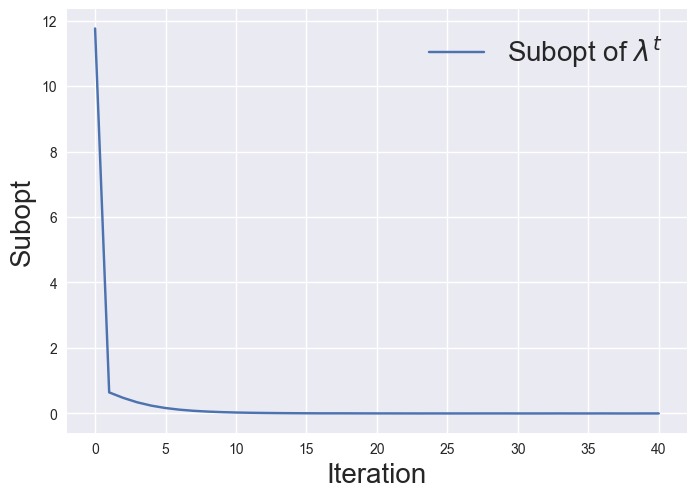

In [23]:
plot_lines([np.array(subopts)], [r"Subopt of $\lambda^t$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

**Theoretical Derivation of REPS**

Prove that the iterates of REPS are equivalent to the iterates produced by the following updates:

$$ \lambda_{k+1} = \mathrm{argmax}_{\lambda} \left( \langle \lambda, r \rangle - \frac{1}{\eta} \left\langle \lambda,~ \log\left(\frac{\lambda}{\lambda_k}\right) \right\rangle \right) \quad \text{s.t.} \quad E^T \lambda = \gamma P^T \lambda + (1 - \gamma) \mu. $$

(*Hint:* Check the slides of lecture if you do not know where to start.)

**Answer:**

**Proof:**

We form the **Lagrangian** of the constrained maximization problem, introducing $V \in \mathbb{R}^{|\mathcal{S}|}$ as the Lagrange multiplier for the equality constraint $E^T\lambda - \gamma P^T\lambda = (1-\gamma)\mu$:

$$
\mathcal{L}_{\text{KL}}(\lambda, V) = \langle \lambda, r \rangle - \frac{1}{\eta}\langle \lambda, \log\tfrac{\lambda}{\lambda_k}\rangle - \langle V,\, E^T\lambda - \gamma P^T\lambda - (1-\gamma)\mu \rangle.
$$

Re-arranging the inner product (transposing the matrices),

$$
\langle V, E^T\lambda - \gamma P^T\lambda\rangle = \langle (E - \gamma P)V, \lambda\rangle,
$$

so the Lagrangian becomes

$$
\mathcal{L}_{\text{KL}}(\lambda, V) = \langle \lambda,\; r + (\gamma P - E)V\rangle - \frac{1}{\eta}\langle \lambda, \log\tfrac{\lambda}{\lambda_k}\rangle + (1-\gamma)\langle \mu, V\rangle.
$$

**KKT stationarity condition** (setting $\partial \mathcal{L}_{\text{KL}} / \partial \lambda(s,a) = 0$):

$$
r(s,a) + [(\gamma P - E)V](s,a) - \frac{1}{\eta}\!\left(\log\frac{\lambda(s,a)}{\lambda_k(s,a)} + 1\right) = 0.
$$

Defining the **Bellman advantage** $\delta_k(s,a) = r(s,a) + \gamma\sum_{s'}P(s'|s,a)V(s') - V(s)$, this becomes

$$
\delta_k(s,a) = \frac{1}{\eta}\!\left(\log\frac{\lambda(s,a)}{\lambda_k(s,a)} + 1\right).
$$

Solving for $\lambda(s,a)$:

$$
\lambda(s,a) = \lambda_k(s,a)\cdot\exp\!\bigl(\eta\,\delta_k(s,a) - 1\bigr) \;\propto\; \lambda_k(s,a)\cdot\exp\!\bigl(\eta\,\delta_k(s,a)\bigr),
$$

since $e^{-1}$ is a constant with respect to $(s,a)$ and cancels upon normalization. This is exactly the **REPS multiplicative update** $\lambda_{k+1} \propto \lambda_k \cdot \exp(\eta\,\delta_k)$.

**Identifying $V_k$:** The optimal Lagrange multiplier $V_k$ is obtained by minimizing the **dual function**:

$$
g(V) = \max_{\lambda}\,\mathcal{L}_{\text{KL}}(\lambda, V).
$$

Using the standard result for KL-regularized maximization, $\max_\lambda[\langle\lambda,\delta\rangle - \tfrac{1}{\eta}\text{KL}(\lambda\|\lambda_k)] = \tfrac{1}{\eta}\log\langle\lambda_k,\exp(\eta\delta)\rangle$, we get

$$
g(V) = (1-\gamma)\langle\mu, V\rangle + \frac{1}{\eta}\log\langle \lambda_k,\, \exp(\eta\,(r + (\gamma P - E)V))\rangle,
$$

which is exactly the **REPS loss** $\mathcal{L}(\lambda_k, V)$. Therefore

$$
V_k = \operatorname*{argmin}_{V}\, g(V) = \operatorname*{argmin}_{V}\, \mathcal{L}(\lambda_k, V),
$$

which is precisely the inner minimization step implemented via `minimize_reps_loss`. $\blacksquare$

**Plot the constraints violation**

Plot the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $, varying the parameter `maxiter` of the `scipy.minimize` function.

(To be clear: in the code above, modify this line ```minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})``` and plot for varying `maxiter`.)

Running REPS with maxiter=1...
Running REPS with maxiter=5...
Running REPS with maxiter=20...
Running REPS with maxiter=100...
Running REPS with maxiter=1000...


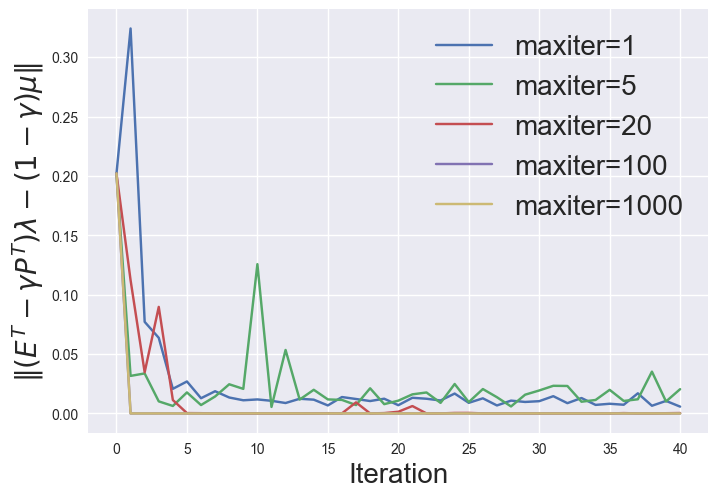

In [24]:

# Experiment: compare constraint violations for different maxiter values
K_exp = 40
maxiter_values = [1, 5, 20, 100, 1000]

def run_reps_with_maxiter(maxiter, K=K_exp):
    """Run REPS for K iterations using a given maxiter for the inner CG optimizer."""
    mu_exp = np.ones((gridworld.n_states, 1)) / gridworld.n_states

    def minimize_reps_loss_exp(lambda_, eta, initial):
        loss = lambda V: reps_loss(lambda_, V, eta, initial)
        V = minimize(loss, np.zeros(gridworld.n_states), method="CG", options={'maxiter': maxiter})
        return V.x

    lambda_ = np.ones(gridworld.n_states * gridworld.n_actions) / gridworld.n_states / gridworld.n_actions
    errors = []
    errors.append(np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1 - gridworld.gamma) * mu_exp))

    for k in range(K):
        eta = 1 / np.sqrt(k + 1)
        V = minimize_reps_loss_exp(lambda_, eta, lambda_)
        delta = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions) + build_matrix(gridworld).dot(V)
        new_lambda_ = lambda_ * np.exp(eta * delta)
        new_lambda_ /= np.sum(new_lambda_)
        lambda_ = new_lambda_
        errors.append(np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1 - gridworld.gamma) * mu_exp))

    return errors

# Run for each maxiter
all_errors = []
labels = []
for maxiter in maxiter_values:
    print(f"Running REPS with maxiter={maxiter}...")
    errors = run_reps_with_maxiter(maxiter)
    all_errors.append(np.array(errors))
    labels.append(f"maxiter={maxiter}")

# Plot
plot_lines(all_errors, labels,
           ["Iteration", r"$\|(E^T - \gamma P^T)\lambda - (1-\gamma)\mu\|$"],
           "figs", "constraints_maxiter_comparison.pdf", show=True)


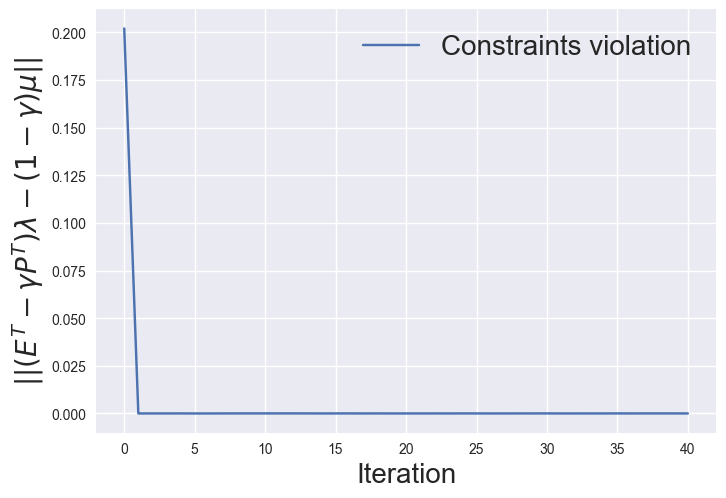

In [25]:
plot_lines([np.array(feasibility_errors)], [r"Constraints violation"], ["Iteration", "$|| (E^T - \gamma P^T)\lambda - (1 - \gamma) \mu ||$"], "figs", "constraints.pdf", show = True)

**Question**

Empirically, is the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $ higher for high or low values of `maxiter`?

Explain why this is the case.

**Answer:** 
Empirically, the constraint violation

$||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $

is typically higher for smaller values of `maxiter`, and lower for larger values of `maxiter`.

This happens because `maxiter` controls how accurately the inner optimization over \( V \) is solved.

When `maxiter` is **too small**: The optimizer stops early before reaching a good approximation of the minimizer of the REPS dual objective, which leads to an inaccurate computation of \( V_k \). As a result, the update of \( \lambda \) is less consistent with the primal flow constraint. This leads to a **larger constraint violation**.

When `maxiter` is **larger**: With larger maxiter. The optimization over \( V \) is solved more accurately. and the induced occupancy measure is therefore closer to satisfying the feasibility condition. This leads to a **smaller constraint violation**.

**Question:**

Strictly speaking, are the actual iterates $\lambda_k$ in the implementation above valid occupancy measures? In other words, is $E^T \lambda_k = \gamma P^T \lambda_k + (1 - \gamma) \mu$ strictly satisfied for all iterates? Explain why this is (not) the case.

**Answer:**

No, the iterates $\lambda_k$ are **not** strictly valid occupancy measures in general.

In the theoretical formulation of REPS, the update

$$\lambda_{k+1} \propto \lambda_k \cdot \exp(\eta\, \delta_k), \quad \delta_k = r + \gamma P V_k - E V_k$$

is equivalent to the constrained mirror descent step where $V_k$ plays the role of the **Lagrange multiplier** enforcing $E^T\lambda = \gamma P^T\lambda + (1-\gamma)\mu$. Only when $V_k$ is the **exact** minimizer of the REPS loss $\mathcal{L}(\lambda_k, \cdot)$ does the update guarantee that $\lambda_{k+1}$ lies on the constraint manifold.

In practice, $V_k$ is computed by `scipy.minimize` with a finite `maxiter`, so it is only an **approximate** minimizer. As a result, the Lagrange multiplier is imprecise, and the constraint

$$E^T \lambda_k = \gamma P^T \lambda_k + (1-\gamma)\mu$$

is only approximately satisfied. This is exactly what the feasibility error plot measures: the norm $\|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|$ is small but nonzero, and decreases as `maxiter` increases.

**Plot of the suboptimality of the policies extracted from the $\lambda^k$'s**

*Extract the policies from the $\lambda^k$-iterates:* $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda_k(s,a)}.$$

In [26]:
def extract_policies_from_occ_measures(occ_measures): # extract the policies from the occupancy measures
    policies = []
    for occ_measure in occ_measures:
        policy = np.zeros((gridworld.n_states, gridworld.n_actions)) # initialize the policy
        occ_measure = occ_measure.reshape(gridworld.n_states, -1) # reshape the occupancy measure
        states_occ_measure = occ_measure.sum(axis=1) # compute the occupancy measure over states (not state-action pairs)
        for s in range(gridworld.n_states):
            if states_occ_measure[s] > 0:
                policy[s] = occ_measure[s] / states_occ_measure[s] # normalize by state occupancy
            else:
                policy[s] = np.ones(gridworld.n_actions) / gridworld.n_actions # uniform policy for unvisited states
        policies.append(policy)
        
    return policies


In [27]:
policies = extract_policies_from_occ_measures(iterates)

*Extract the occupancy measures from the policies:* $$ \lambda_{\pi_{\lambda^k}}(s,a) = (1 - \gamma)\sum^{\infty}_{t=0} \gamma^t \mathbb{P}[s_t=s,a_t=a | s_0 \sim \mu, \pi_{\lambda^k}].$$

In [28]:
def extract_occ_measures_from_policies(policies): # extract the occupancy measures from the policies (we do not require you to follow this)
    occ_measures = []
    for policy in policies:
        v = - (1 - gridworld.gamma)*(mu.repeat(gridworld.n_actions,axis=1)*policy).reshape(gridworld.n_states*gridworld.n_actions)
        matrix = np.eye(gridworld.n_states*gridworld.n_actions)
        T_pi = np.expand_dims(gridworld.T.transpose((1,0,2)),axis=3).repeat(gridworld.n_actions, axis=3)
        pi_tensor = np.expand_dims(policy, axis=(0,1)).repeat(T_pi.shape[0], axis=0).repeat(T_pi.shape[1], axis=1)
        T_pi = T_pi*pi_tensor
        matrix = gridworld.gamma*T_pi.reshape(gridworld.n_states*gridworld.n_actions,gridworld.n_states*gridworld.n_actions)- matrix
        occ_measure = np.linalg.solve(matrix.T, v)
        occ_measures.append(occ_measure)
    return occ_measures

In [29]:
occ_measures = extract_occ_measures_from_policies(policies)

*Check whether $\lambda_{\pi_{\lambda_k}} = \lambda_k$*:

In [30]:
# compute the difference between the occupancy measures and the iterates
diff_occ_measures = [np.linalg.norm(occ_measure - iterate) for occ_measure, iterate in zip(occ_measures, iterates)] 

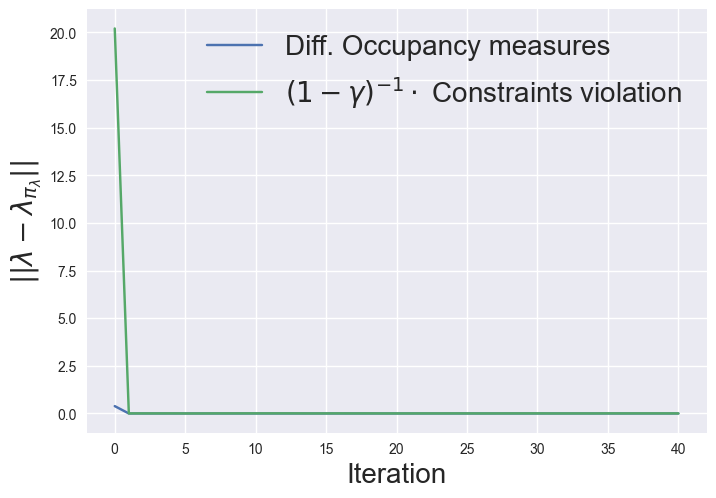

In [31]:
# plot the difference between the occupancy measures and the iterates
plot_lines([np.array(diff_occ_measures), np.array(feasibility_errors)/(1 - gridworld.gamma)], [r"Diff. Occupancy measures", r"$(1-\gamma)^{-1}\cdot$ Constraints violation"], ["Iteration", "$|| \lambda - \lambda_{\pi_\lambda}||$"], "figs", "diff_occ_measures.pdf", show = True)

**Questions**

- How does the norm of the difference $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ relate to the constraint violation $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ ?

- If $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ is small, can you conclude that $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ is also small ? 

*Hint: For both, you can answer leveraging the result in Lemma 3 of https://arxiv.org/pdf/2112.14004.pdf*

- As a consequence how is $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ affected by the value of `maxiter`?

*Hint:* Recall your empirical finding about the impact of `maxiter` (above).

***Answer:***

**Question 1: Relation between $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ and the constraint violation**

By **Lemma 3** of [Swann et al. (2021)](https://arxiv.org/pdf/2112.14004.pdf), for any $\lambda \geq 0$, the following inequality holds:

$$\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|_1 \leq \|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|_1$$

That is, the norm of the difference between $\lambda^k$ and the occupancy measure induced by its greedy policy $\pi_{\lambda^k}$ is **upper bounded** by the Bellman flow constraint violation. This is consistent with the empirical plot, where the curve $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ tracks the rescaled constraint violation $(1-\gamma)^{-1}\cdot\|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|$ closely.

**Question 2: If the constraint violation is small, is $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ also small?**

**Yes.** Directly from the inequality above:

$$\text{small } \|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\| \implies \text{small } \|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$$

If $\lambda^k$ approximately satisfies the Bellman flow constraints, then it is close to the true occupancy measure of the policy it induces. The converse is not guaranteed by Lemma 3.

**Question 3: How is $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ affected by `maxiter`?**

From the previous empirical finding, a larger `maxiter` leads to a smaller constraint violation $\|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|$, because the inner CG optimizer has more iterations to converge to an accurate $V_k$.

By the bound from Lemma 3:
- **Small `maxiter`**: large constraint violation $\Rightarrow$ large $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ $\Rightarrow$ $\lambda^k$ is a poor proxy for the true occupancy measure $\lambda_{\pi_{\lambda^k}}$.
- **Large `maxiter`**: small constraint violation $\Rightarrow$ small $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ $\Rightarrow$ $\lambda^k$ closely approximates $\lambda_{\pi_{\lambda^k}}$.

Therefore, `maxiter` directly controls the quality of the occupancy measure approximation through the constraint violation.


**Evaluate the extracted policies**

In this section, we compute the value functions of the extracted policies which is $V^{\pi_{\lambda^k}}$

In [32]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) #calculate Q-value
            for s in range(env.n_states):
                v[s] = pi[s].dot(q[s]) #calculate value function by $v(s) = max_a Q(s,a)$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [33]:
def check_correctness(policies):
    values = evaluate_policy_sequence(policies, gridworld) # evaluate the policies
    for policy,v in zip(policies,values):
        state_occ_measure = solver.mu_policy(policy, stochastic=True) # compute the state occupancy measure
        occ_measure = np.expand_dims(state_occ_measure, axis=1).repeat(gridworld.n_actions, axis=1)*policy
        primal = occ_measure.reshape(gridworld.n_states*gridworld.n_actions).dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the primal value
        dual = (1 - gridworld.gamma)*mu.T.dot(v) # compute the dual value
        assert primal - dual < 1e-7
    return [ (1 - gridworld.gamma)*mu.T.dot(v) for v in values] # return the values

**Question**

Do you expect $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$ to be (approximately) equal to or (very) different from $\langle \lambda^k, r \rangle $? Does the answer depend on the value of `maxiter`?

*Hint: Recall that $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle = \langle \lambda_{\pi_{\lambda^k}}, r \rangle $ and argue using your previous answer concerning the term $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$.*

**Answer:**

Since $(1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle = \langle \lambda_{\pi_{\lambda^k}}, r \rangle$, we have:

$$|(1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle - \langle \lambda^k, r \rangle| = |\langle \lambda_{\pi_{\lambda^k}} - \lambda^k, r \rangle| \leq \|r\|_\infty \cdot \|\lambda^k - \lambda_{\pi_{\lambda^k}}\|_1$$

From the previous question, we know that $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ is bounded by (a constant times) the constraint violation $\|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|$.

Therefore: **High `maxiter`**: the inner CG optimizer computes $V^k$ accurately, so the constraint violation is small, meaning $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ is small, and thus $(1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle \approx \langle \lambda^k, r \rangle$. **Low `maxiter`**: $V^k$ is inaccurate, constraint violation is large, $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ can be large, so the two quantities may differ significantly.

In summary, the answer **does depend on `maxiter`**: the two quantities are approximately equal when `maxiter` is large, and can be very different when `maxiter` is small.

In [34]:
policy_values = check_correctness(policies) # check that $(1 - \gamma)\langle \mu, V^{\pi} \rangle = \langle \lambda_{\pi}, r \rangle $ for all policies.
policy_subopts = (1 - gridworld.gamma)*mu.T.dot(solver.v) - policy_values # compute the suboptimality of the policies

**Plot the suboptimalities**

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - (1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$.

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - \langle \lambda^k, r \rangle$.

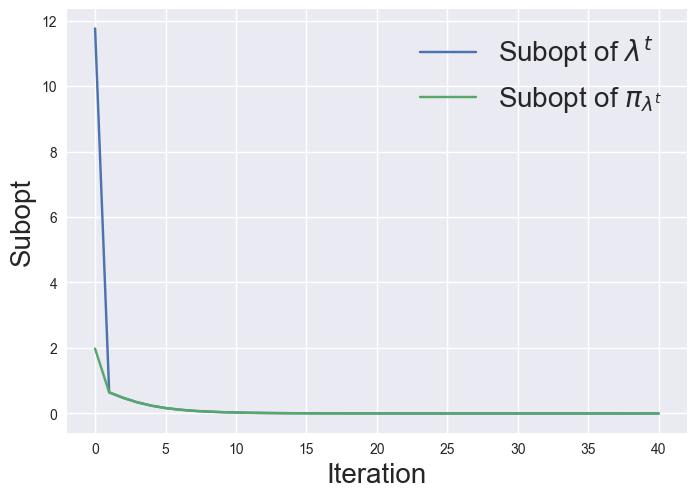

In [35]:
plot_lines([np.array(subopts), policy_subopts.flatten()], [r"Subopt of $\lambda^t$", r"Subopt of $\pi_{\lambda^t}$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

## Ex 4: Lagrangian methods [ 20 points ]

In this section we compute an optimal policy finding a saddle point of the Lagrangian $\mathcal{L}(\lambda, V)$, defined as follows

$$
\mathcal{L}(\lambda, V) = \langle \lambda, r \rangle + \langle (1 - \gamma) \mu + \gamma P^T \lambda - E^T \lambda, V \rangle .
$$

Finding a saddle point of the Lagrangian means solving the following problem:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathbb{R}^{|\mathcal{S}|}} \mathcal{L}(\lambda, V).
$$

By slide 6 in Lecture 3 it should be clear that there exists a saddle point pair $\lambda^\star, V^\star$ such that $|| V^\star ||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma}$. Therefore, we can consider looking for a saddle point over a restricted domain $\mathcal{V} = \{ V : ||V||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma} \}$:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathcal{V}} \mathcal{L}(\lambda, V).
$$

At this point we solve this problem with gradient descent ascent updates 

$$
\lambda^{k+1} \propto \lambda^k \odot \exp(\eta_{\lambda} \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k)),
$$

$$
V^{k+1} = \Pi_{\mathcal{V}}[V^k - \eta_V \nabla_{V} \mathcal{L}(\lambda^k, V^k)].
$$

**Question**: 

Compute the following gradients:

$$  \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k) = r + \gamma P V^k - E V^k $$

$$ \nabla_{V} \mathcal{L}(\lambda^k, V^k) = (1-\gamma)\mu + \gamma P^T \lambda^k - E^T \lambda^k $$

**Answer**:

Gradients of the Lagrangian

The Lagrangian is
$$
\mathcal{L}(\lambda, V)
=
\langle \lambda, r \rangle
+
\left\langle (1-\gamma)\mu + \gamma P^T \lambda - E^T \lambda,\; V \right\rangle .
$$

Using the identities
$$
\langle P^T\lambda, V\rangle = \langle \lambda, PV\rangle,
\qquad
\langle E^T\lambda, V\rangle = \langle \lambda, EV\rangle,
$$
we can rewrite it as
$$
\mathcal{L}(\lambda, V)
=
\langle \lambda,\; r + \gamma PV - EV\rangle
+
(1-\gamma)\langle \mu, V\rangle.
$$

Therefore, the gradients are

$$
\nabla_{\lambda} \mathcal{L}(\lambda^k, V^k)
=
r + \gamma P V^k - E V^k
$$

and

$$
\nabla_{V} \mathcal{L}(\lambda^k, V^k)
=
(1-\gamma)\mu + \gamma P^T \lambda^k - E^T \lambda^k.
$$

In coordinate form, for each $(s,a)$,
$$
\left[\nabla_{\lambda} \mathcal{L}(\lambda^k, V^k)\right](s,a)
=
r(s,a) + \gamma \sum_{s'} P(s'|s,a)\, V^k(s') - V^k(s),
$$
and for each $s$,
$$
\left[\nabla_{V} \mathcal{L}(\lambda^k, V^k)\right](s)
=
(1-\gamma)\mu(s)
+
\gamma \sum_{s',a'} P(s|s',a')\, \lambda^k(s',a')
-
\sum_a \lambda^k(s,a).
$$

**Question:**

Which of the following conditions ensure that the policy $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal ?

(a) $$\langle \lambda^\star, r \rangle - \langle \lambda^k, r \rangle \leq \epsilon.$$
(b) $$(1 - \gamma)\langle \mu, V^\star \rangle - \langle \mu, V^k \rangle \leq \epsilon.$$
(c) $$ \mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi^{\lambda^k}}) \leq \epsilon.$$

Answer (a),(b) or (c).

**Answer**

(c)

### * Question [20 points]

Prove that the answer you gave at the question above implies that the policy $$\pi_{\lambda_k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal.
*Recall:* A policy $\pi$ is $\epsilon$-suboptimal if $ (1 - \gamma)  \langle\mu , V^\star - V^{\pi} \rangle\leq \epsilon$

 **Answer**

**Proof:**

We are given the condition: 
$$\mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi}) \leq \epsilon$$
Our goal is to prove that this implies $(1 - \gamma) \langle \mu, V^\star - V^{\pi} \rangle \leq \epsilon$, where $\pi$ is the extracted policy $\pi(a|s) = \frac{\lambda^k(s,a)}{\sum_{a'}\lambda^k(s,a')}$.

Recall the Lagrangian:
$$\mathcal{L}(\lambda, V) = \langle \lambda, r + \gamma P V - V \rangle + (1 - \gamma)\langle \mu, V \rangle$$

**Step 1: Simplify $\mathcal{L}(\lambda^k, V^{\pi})$ using the Bellman Equation**
First, let's denote the state marginal of $\lambda^k$ as $\lambda^k(s) = \sum_{a'} \lambda^k(s,a')$. From the policy extraction formula, we can write the substitution:
$$\lambda^k(s,a) = \lambda^k(s) \pi(a|s)$$

Now, expand the Lagrangian for $(\lambda^k, V^{\pi})$:
$$\mathcal{L}(\lambda^k, V^{\pi}) = \sum_{s,a} \lambda^k(s,a) \Big[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V^{\pi}(s') - V^{\pi}(s) \Big] + (1 - \gamma)\langle \mu, V^{\pi} \rangle$$

Substitute $\lambda^k(s,a)$ with $\lambda^k(s) \pi(a|s)$ and factor out $\lambda^k(s)$:
$$\mathcal{L}(\lambda^k, V^{\pi}) = \sum_s \lambda^k(s) \left( \sum_a \pi(a|s) \Big[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V^{\pi}(s') \Big] - V^{\pi}(s) \sum_a \pi(a|s) \right) + (1 - \gamma)\langle \mu, V^{\pi} \rangle$$

Since $\sum_a \pi(a|s) = 1$, and by the Bellman expectation equation for policy $\pi$, we have:
$$V^{\pi}(s) = \sum_a \pi(a|s) \Big[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V^{\pi}(s') \Big]$$

Therefore, the entire term inside the large parentheses is exactly $V^{\pi}(s) - V^{\pi}(s) = 0$. The first term completely vanishes:
$$\mathcal{L}(\lambda^k, V^{\pi}) = (1 - \gamma)\langle \mu, V^{\pi} \rangle$$

**Step 2: Simplify $\mathcal{L}(\lambda^\star, V^k)$ using Flow Conservation**
Expand the Lagrangian for $(\lambda^\star, V^k)$:
$$\mathcal{L}(\lambda^\star, V^k) = \langle \lambda^\star, r \rangle + \langle \lambda^\star, \gamma P V^k - V^k \rangle + (1 - \gamma)\langle \mu, V^k \rangle$$

Because $\lambda^\star$ is the optimal physical occupancy measure, it must strictly satisfy the flow conservation constraint for all states $s$:
$$\sum_a \lambda^\star(s,a) - \gamma \sum_{s', a'} \lambda^\star(s',a')P(s|s',a') = (1 - \gamma)\mu(s)$$

Take the inner product of both sides with the value vector $V^k$ (i.e., multiply by $V^k(s)$ and sum over all $s$):
$$\sum_s V^k(s) \sum_a \lambda^\star(s,a) - \gamma \sum_s V^k(s) \sum_{s', a'} \lambda^\star(s',a')P(s|s',a') = (1 - \gamma)\sum_s \mu(s) V^k(s)$$

Rewriting this in vector/inner-product notation yields the exact substitution:
$$\langle \lambda^\star, V^k \rangle - \langle \lambda^\star, \gamma P V^k \rangle = (1 - \gamma)\langle \mu, V^k \rangle$$

Multiply by $-1$ to match the Lagrangian terms:
$$\langle \lambda^\star, \gamma P V^k - V^k \rangle = - (1 - \gamma)\langle \mu, V^k \rangle$$

Substitute this back into the expanded Lagrangian:
$$\mathcal{L}(\lambda^\star, V^k) = \langle \lambda^\star, r \rangle - (1 - \gamma)\langle \mu, V^k \rangle + (1 - \gamma)\langle \mu, V^k \rangle = \langle \lambda^\star, r \rangle$$

Finally, by the definition of the occupancy measure, the expected reward of $\lambda^\star$ is the expected return of the optimal policy:
$$\mathcal{L}(\lambda^\star, V^k) = \langle \lambda^\star, r \rangle = (1 - \gamma)\langle \mu, V^\star \rangle$$

**Step 3: Combine and Conclude**
Substitute the simplified results from Step 1 and Step 2 back into the initial assumption:
$$\mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi}) \leq \epsilon$$
$$(1 - \gamma)\langle \mu, V^\star \rangle - (1 - \gamma)\langle \mu, V^{\pi} \rangle \leq \epsilon$$
$$(1 - \gamma)\langle \mu, V^\star - V^{\pi} \rangle \leq \epsilon$$

By definition, this proves that the extracted policy $\pi_{\lambda^k}$ is $\epsilon$-suboptimal.